# Peut-on deviner où un fonds est investi en regardant seulement sa performance ?

Fonds étudié : **Fidelity Contrafund (FCNTX)**.
Références : 11 ETF sectoriels SPDR. Un ETF sectoriel sert de « règle graduée » :
si le fonds évolue comme l'ETF technologie, il a probablement beaucoup de technologie.
Le fonds ne détient pas ces ETF.

Prérequis : avoir lancé `python fetch_data.py`, qui crée `monthly_returns.csv`.

## 1. Charger les données

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

FUND = "FCNTX"
data = pd.read_csv("monthly_returns.csv", index_col=0, parse_dates=True)
y = data[FUND].values
X = data.drop(columns=FUND)
etfs = list(X.columns)
X = X.values

# Nom lisible du secteur suivi par chaque ETF (pour les tableaux et le graphique)
SECTEURS = {
    "XLK": "Tech", "XLC": "Communication", "XLF": "Finance",
    "XLY": "Conso. discrétionnaire", "XLV": "Santé", "XLI": "Industrie",
    "XLP": "Conso. de base", "XLB": "Matériaux", "XLE": "Énergie",
    "XLU": "Services publics", "XLRE": "Immobilier",
}

print(f"{len(data)} mois, de {data.index[0]:%Y-%m} à {data.index[-1]:%Y-%m}")
data.head()

98 mois, de 2018-07 à 2026-08


,FCNTX,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
Date,,,,,,,,,,,,
2018-07-31,0.019384,0.028586,-0.021603,0.015539,0.051147,0.073851,0.020872,0.039589,0.010395,0.015974,0.065540,0.018024
2018-08-31,0.045086,-0.007701,0.014858,-0.034751,0.013596,0.002340,0.065989,0.003920,0.024206,0.012881,0.043293,0.051047
2018-09-30,0.001422,-0.017954,-0.000963,0.024460,-0.022155,0.021774,-0.000192,0.009872,-0.026461,-0.006483,0.029542,0.005304
2018-10-31,-0.097232,-0.091835,-0.060408,-0.113282,-0.047135,-0.108674,-0.080048,0.020026,-0.015946,0.019753,-0.067788,-0.101006
2018-11-30,0.007075,0.038015,-0.022372,-0.015634,0.026256,0.038065,-0.019625,0.022723,0.054846,0.035388,0.080834,0.024767


## 2. Contrôle : les données sont-elles bonnes ?

On recompose les rendements mensuels en rendements annuels et on compare à ceux publiés par Fidelity.

In [2]:
publie = {2019: 29.98, 2020: 32.58, 2021: 24.36, 2022: -28.26,
          2023: 39.33, 2024: 35.97, 2025: 21.80}

annuel = (1 + data[FUND]).groupby(data.index.year).prod() - 1
controle = pd.DataFrame({
    "calculé (%)": (annuel * 100).round(2),
    "publié (%)": pd.Series(publie),
})
controle["écart"] = (controle["calculé (%)"] - controle["publié (%)"]).round(2)
controle.dropna()

,calculé (%),publié (%),écart
2019,30.00,29.98,0.02
2020,32.48,32.58,-0.10
2021,24.52,24.36,0.16
2022,-28.31,-28.26,-0.05
2023,39.37,39.33,0.04
2024,36.00,35.97,0.03
2025,21.76,21.80,-0.04


Les écarts doivent être de quelques dixièmes de point au plus. Sinon, il y a un problème de données
(devise, dividendes, dates) à régler avant de continuer.

Résultat : tous les écarts restent sous 0,2 point, les données sont utilisables.

## 3. La reconstruction

On cherche les poids `w` (positifs, somme = 100 %) tels que :

**rendement du fonds ≈ α + Σ wᵢ × rendement de l'ETF i**

`α` est un écart moyen mensuel que les ETF n'expliquent pas (frais du fonds, choix du gérant).
On cherche les poids qui rendent l'écart entre le fonds et la combinaison d'ETF le plus petit possible.

In [3]:
def reconstruire(X, y):
    n = X.shape[1]

    def erreur(p):                      # p = [w1..wn, alpha]
        w, a = p[:n], p[n]
        return np.sum((y - a - X @ w) ** 2)

    depart = np.append(np.full(n, 1 / n), 0.0)
    contraintes = {"type": "eq", "fun": lambda p: np.sum(p[:n]) - 1}
    bornes = [(0, 1)] * n + [(None, None)]
    res = minimize(erreur, depart, method="SLSQP",
                   bounds=bornes, constraints=contraintes)
    return res.x[:n], res.x[n]

w, alpha = reconstruire(X, y)
estime = pd.Series(w, index=etfs)

ajuste = alpha + X @ w
r2 = 1 - np.sum((y - ajuste) ** 2) / np.sum((y - y.mean()) ** 2)

print(f"Qualité de la ressemblance (R²) : {r2:.3f}")
print(f"α : {alpha * 12 * 100:+.2f} % par an (approx.)")
(estime * 100).round(1).sort_values(ascending=False).rename(SECTEURS).to_frame("poids estimé (%)")

Qualité de la ressemblance (R²) : 0.934
α : +0.82 % par an (approx.)


,poids estimé (%)
Tech,30.6
Communication,29.7
Santé,16.8
Conso. discrétionnaire,14.5
Industrie,8.5
Énergie,0.0
Matériaux,0.0
Conso. de base,0.0
Finance,0.0
Services publics,0.0


Le R² indique la part des variations du fonds que la combinaison d'ETF reproduit
(1 = parfaitement). Un R² élevé ne veut pas dire que chaque poids est fiable : les ETF sectoriels
se ressemblent, donc plusieurs combinaisons peuvent donner un résultat proche.
La section suivante mesure cette incertitude.

## 4. Des intervalles plutôt qu'un chiffre : le bootstrap par blocs

**Le principe du bootstrap.** On ne dispose que d'un seul historique de 98 mois. Pour savoir si
le résultat est solide, on fabrique de nombreux historiques « possibles » en retirant au hasard,
avec remise, des morceaux de l'historique réel. On refait l'estimation sur chacun. Si les poids
changent beaucoup d'un tirage à l'autre, l'estimation est fragile ; s'ils bougent peu, elle est fiable.

**Pourquoi par blocs de 3 mois.** Les rendements d'un mois ne sont pas indépendants de ceux des mois
voisins (tendances, crises qui durent). Tirer des mois isolés casserait ces enchaînements. On tire donc
des blocs de 3 mois consécutifs, recollés jusqu'à retrouver 98 mois.

**Réglages** :
- graine aléatoire fixée à 42 pour que le calcul soit reproductible ;
- 2000 tirages, fixés après un premier essai à 200 : l'estimation principale n'en dépend pas,
  et les bornes bougent d'au plus 1,3 point ; 2000 tirages les rendent plus stables ;
- intervalle = de 5 % à 95 % des poids obtenus (90 % des tirages tombent dedans) ;
- **valeur principale = l'estimation sur les 98 mois réels** (section 3), qui fait 100 %.

**Note sur la valeur principale.** Un premier essai utilisait la moyenne des tirages. Ce choix,
fait après avoir vu un résultat, a été écarté : les poids ne pouvant pas descendre sous 0, la moyenne
des tirages remonte artificiellement les petits secteurs (un secteur estimé à 0 sur les données
réelles obtient une moyenne positive). Elle reste affichée à titre indicatif.

In [4]:
N_TIRAGES = 2000
TAILLE_BLOC = 3          # mois consécutifs par bloc
SEED = 42
rng = np.random.default_rng(SEED)

def tirage_blocs(n, taille, rng):
    """Indices d'un historique bootstrap : blocs de mois consécutifs tirés avec remise, recollés jusqu'à n mois."""
    debuts = rng.integers(0, n - taille + 1, size=int(np.ceil(n / taille)))
    return np.concatenate([np.arange(d, d + taille) for d in debuts])[:n]

tirages = []
for _ in range(N_TIRAGES):
    idx = tirage_blocs(len(y), TAILLE_BLOC, rng)
    tirages.append(reconstruire(X[idx], y[idx])[0])
boot = pd.DataFrame(np.array(tirages) * 100, columns=etfs)

est = estime * 100                      # valeur principale : estimation sur les données réelles
bas, haut = boot.quantile(0.05), boot.quantile(0.95)
moy_tirages = boot.mean()               # indicatif seulement (remonte les petits poids)

reel_dedans = (est >= bas - 1e-9) & (est <= haut + 1e-9)
print(f"{N_TIRAGES} tirages")
print(f"Estimation réelle dans son propre intervalle : {reel_dedans.sum()} secteurs sur {len(etfs)}")
print(f"Largeur moyenne des intervalles : {(haut - bas).mean():.1f} points")
resume = pd.DataFrame({"estimé (%)": est, "bas (5 %)": bas, "haut (95 %)": haut,
                       "moyenne des tirages (%)": moy_tirages,
                       "tirages à 0 (%)": (boot < 0.5).mean() * 100}).round(1)
resume.sort_values("estimé (%)", ascending=False).rename(SECTEURS)

2000 tirages
Estimation réelle dans son propre intervalle : 11 secteurs sur 11
Largeur moyenne des intervalles : 8.2 points


,estimé (%),bas (5 %),haut (95 %),moyenne des tirages (%),tirages à 0 (%)
Tech,30.6,25.0,39.9,31.2,0.0
Communication,29.7,21.9,37.8,29.6,0.0
Santé,16.8,8.9,21.8,15.5,0.1
Conso. discrétionnaire,14.5,6.6,21.5,14.1,0.2
Industrie,8.5,0.0,16.6,7.4,11.3
Énergie,0.0,0.0,0.0,0.0,99.6
Matériaux,0.0,0.0,1.4,0.2,92.2
Conso. de base,0.0,0.0,5.4,0.8,80.6
Finance,0.0,0.0,3.1,0.4,84.0
Services publics,0.0,0.0,4.7,0.8,70.4


## 5. Comparaison avec les poids publiés

Source : fiche produit Fidelity Contrafund (*Fact Sheet*), tableau « Sector Diversification »,
au **30 juin 2026**. Les secteurs y suivent la classification GICS, comme les ETF SPDR Select Sector.
Les pourcentages sont saisis tels que publiés (en % de l'actif net) ; le notebook les ramène
à 100 % sur les 11 secteurs.

In [5]:
# Correspondance secteur publié -> ETF (fixée avant de regarder les résultats)
# Valeurs publiées, en % (Fidelity, fiche au 30/06/2026, secteurs GICS)
publies_bruts = {
    "XLK":  30.63,  # Information Technology
    "XLC":  22.28,  # Communication Services
    "XLF":  10.39,  # Financials
    "XLY":   9.95,  # Consumer Discretionary
    "XLV":   9.16,  # Health Care
    "XLI":   7.84,  # Industrials
    "XLP":   3.72,  # Consumer Staples
    "XLB":   1.73,  # Materials
    "XLE":   2.65,  # Energy
    "XLU":   0.03,  # Utilities
    "XLRE":  0.08,  # Real Estate
}

remplis = all(v is not None for v in publies_bruts.values())
if remplis:
    pub = pd.Series(publies_bruts).reindex(etfs).astype(float)
    pub = pub / pub.sum() * 100          # renormalisation sur les 11 secteurs
else:
    print("Poids publiés non renseignés : seuls les poids estimés seront affichés.")

In [6]:
# est : estimation sur les données réelles ; bas, haut : intervalle du bootstrap (section 4)
if remplis:
    tableau = pd.DataFrame({"estimé (%)": est, "bas (5 %)": bas, "haut (95 %)": haut,
                            "publié (%)": pub}).round(1)
    tableau["écart"] = (est - pub).round(1)
    sens = np.where(pub > haut, "sous-estimé", np.where(pub < bas, "surestimé", "dans l'intervalle"))
    tableau["poids publié"] = sens
    dedans = pd.Series(sens == "dans l'intervalle", index=etfs)
    ecart_moyen = (est - pub).abs().mean()
    ecart_naif = (100 / len(etfs) - pub).abs().mean()
    largeur = (haut - bas).mean()
    print(f"Écart absolu moyen : {ecart_moyen:.1f} points")
    print(f"Repère : {ecart_naif:.1f} points en répartissant à parts égales (1/11 par secteur)")
    print(f"Poids publié dans l'intervalle : {dedans.sum()} secteurs sur {len(etfs)} "
          f"(attendu pour un intervalle à 90 % : environ {0.9 * len(etfs):.0f})")
    print(f"Largeur moyenne des intervalles : {largeur:.1f} points")
    display(tableau.sort_values("publié (%)", ascending=False).rename(SECTEURS))
else:
    display(resume.rename(SECTEURS))

Écart absolu moyen : 3.5 points
Repère : 7.0 points en répartissant à parts égales (1/11 par secteur)
Poids publié dans l'intervalle : 7 secteurs sur 11 (attendu pour un intervalle à 90 % : environ 10)
Largeur moyenne des intervalles : 8.2 points


,estimé (%),bas (5 %),haut (95 %),publié (%),écart,poids publié
Tech,30.6,25.0,39.9,31.1,-0.5,dans l'intervalle
Communication,29.7,21.9,37.8,22.6,7.0,dans l'intervalle
Finance,0.0,0.0,3.1,10.6,-10.6,sous-estimé
Conso. discrétionnaire,14.5,6.6,21.5,10.1,4.4,dans l'intervalle
Santé,16.8,8.9,21.8,9.3,7.5,dans l'intervalle
Industrie,8.5,0.0,16.6,8.0,0.5,dans l'intervalle
Conso. de base,0.0,0.0,5.4,3.8,-3.8,dans l'intervalle
Énergie,0.0,0.0,0.0,2.7,-2.7,sous-estimé
Matériaux,0.0,0.0,1.4,1.8,-1.8,sous-estimé
Immobilier,0.0,0.0,0.0,0.1,-0.1,sous-estimé


## 6. Le graphique

Chaque barre bleue est l'estimation sur les données réelles ; le trait fin qui la traverse montre l'intervalle (5 % à 95 % des tirages).

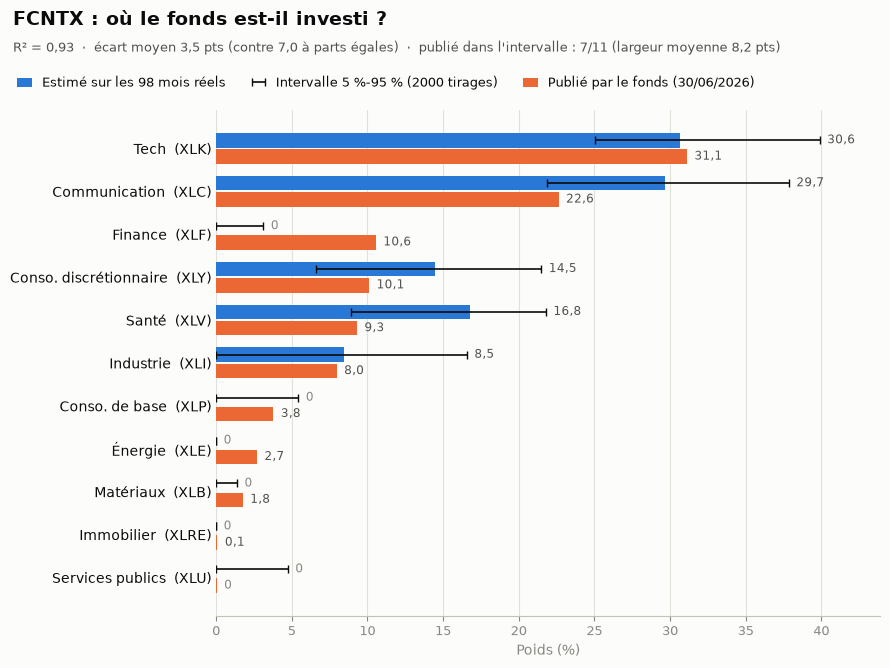

In [7]:
# Barres horizontales triées par poids publié : les noms de secteurs se lisent sans rotation.
# Deux versions (claire et sombre) pour que le README s'adapte au thème de GitHub.
THEMES = {
    "clair":  dict(fond="#fcfcfb", encre="#0b0b0b", encre2="#52514e", discret="#898781",
                   grille="#e1e0d9", axe="#c3c2b7", estime="#2a78d6", publie="#eb6834"),
    "sombre": dict(fond="#1a1a19", encre="#ffffff", encre2="#c3c2b7", discret="#898781",
                   grille="#2c2c2a", axe="#383835", estime="#3987e5", publie="#d95926"),
}

def fr(v, d=1):
    return f"{v:.{d}f}".replace(".", ",")

def graphique(t, chemin=None):
    ordre = (pub if remplis else est).sort_values().index    # plus gros secteur en haut
    yy = np.arange(len(ordre))
    h = 0.38

    fig, ax = plt.subplots(figsize=(9, 6.8), facecolor=t["fond"])
    ax.set_facecolor(t["fond"])

    # Estimé : barre = estimation sur les données réelles, trait = intervalle 5 %-95 % du bootstrap
    ye = yy + h / 2
    v = est[ordre].values
    ax.barh(ye, v, h - 0.04, color=t["estime"], label="Estimé sur les 98 mois réels", zorder=2)
    # np.clip par sécurité : un trait ne peut pas avoir une longueur négative
    xerr = np.clip([v - bas[ordre].values, haut[ordre].values - v], 0, None)
    ax.errorbar(v, ye, xerr=xerr, fmt="none",
                ecolor=t["encre"], elinewidth=1.2, capsize=3, zorder=3,
                label=f"Intervalle 5 %-95 % ({N_TIRAGES} tirages)")
    for yi, vi, hi in zip(ye, v, haut[ordre].values):
        texte = fr(vi) if vi >= 0.05 else "0"
        ax.text(max(vi, hi) + 0.5, yi, texte, va="center", fontsize=8.5,
                color=t["encre2"] if vi >= 0.05 else t["discret"])

    if remplis:
        yp = yy - h / 2
        ax.barh(yp, pub[ordre].values, h - 0.04, color=t["publie"],
                label="Publié par le fonds (30/06/2026)", zorder=2)
        for yi, vi in zip(yp, pub[ordre].values):
            ax.text(vi + 0.5, yi, fr(vi) if vi >= 0.05 else "0", va="center", fontsize=8.5,
                    color=t["encre2"] if vi >= 0.05 else t["discret"])

    ax.set_yticks(yy)
    ax.set_yticklabels([f"{SECTEURS[e]}  ({e})" for e in ordre], color=t["encre"], fontsize=10)
    ax.set_xlim(0, max(haut.max(), pub.max() if remplis else 0) * 1.1)
    ax.set_xlabel("Poids (%)", color=t["discret"])
    ax.tick_params(axis="x", colors=t["discret"], labelsize=9)
    ax.tick_params(axis="y", length=0)
    ax.grid(axis="x", color=t["grille"], linewidth=0.8, zorder=0)
    for cote in ("top", "right", "left"):
        ax.spines[cote].set_visible(False)
    ax.spines["bottom"].set_color(t["axe"])

    # Titre, sous-titre et légende alignés sur le bord gauche de la figure
    fig.text(0.02, 0.975, "FCNTX : où le fonds est-il investi ?", ha="left", va="top",
             fontsize=14, fontweight="bold", color=t["encre"])
    sous_titre = f"R² = {fr(r2, 2)}"
    if remplis:
        sous_titre += (f"  ·  écart moyen {fr(ecart_moyen)} pts (contre {fr(ecart_naif)} à parts égales)"
                       f"  ·  publié dans l'intervalle : {dedans.sum()}/{len(etfs)}"
                       f" (largeur moyenne {fr(largeur)} pts)")
    fig.text(0.02, 0.93, sous_titre, ha="left", va="top", fontsize=9.5, color=t["encre2"])
    leg = fig.legend(loc="upper left", bbox_to_anchor=(0.012, 0.895), ncol=3, frameon=False,
                     fontsize=9, handlelength=1.2)
    for texte in leg.get_texts():
        texte.set_color(t["encre"])

    fig.tight_layout(rect=(0, 0, 1, 0.85))
    if chemin:
        fig.savefig(chemin, dpi=160, facecolor=t["fond"])
    return fig

os.makedirs("figures", exist_ok=True)
graphique(THEMES["sombre"], "figures/estime_vs_publie_sombre.png")
plt.close()
graphique(THEMES["clair"], "figures/estime_vs_publie.png")
plt.show()

## 7. Lecture

- **Les intervalles sont larges** : 8,2 points en moyenne, 13 points sur les six secteurs qui pèsent
  plus de 5 % (technologie de 25,0 à 39,9 %, industrie de 0 à 16,6 %). Un chiffre unique donnait
  une fausse impression de précision.
- **Le poids publié tombe dans l'intervalle pour 7 secteurs sur 11.** Pour un intervalle à 90 %, on en
  attendrait environ 10. Et avec des intervalles aussi larges, y tomber est facile : ce taux ne suffit pas
  à juger la méthode.
- **Les ratés vont tous dans le même sens : sous-estimation.** Pour la finance (0 à 3,1 %, publié 10,6 %),
  l'énergie (0 à 0 %, publié 2,7 %) et les matériaux (0 à 1,4 %, publié 1,8 %), le poids publié est
  au-dessus de la borne haute. L'immobilier est aussi compté comme raté, mais l'écart est négligeable
  (intervalle 0 à 0 %, publié 0,1 %).
- **Ce n'est pas le hasard de l'échantillon.** Le bootstrap mesure cette incertitude-là, et il ne suffit
  pas à expliquer les ratés. La méthode met ces secteurs à 0 dans la grande majorité des tirages
  (84 % pour la finance, plus de 99 % pour l'énergie) : elle a un biais propre, qu'aucun rééchantillonnage
  ne corrige.
- **Repère** : l'écart absolu moyen de l'estimation est de 3,5 points, contre 7,0 points pour une
  répartition à parts égales.

## Limites

- Environ 98 mois pour 11 ETF qui se ressemblent : même avec les intervalles, les poids sont approximatifs.
- Le bootstrap mesure l'incertitude due à l'échantillon, pas les erreurs de la méthode elle-même
  (un secteur que la méthode met à zéro reste à zéro à presque chaque tirage).
- **Un gérant actif change son allocation au fil du temps : c'est son métier.** La méthode suppose
  des poids fixes sur toute la période 2018-2026 ; elle donne au mieux une allocation moyenne et ne
  peut pas suivre ces changements.
- Les deux côtés suivent la classification GICS, mais le fonds détient des titres absents des ETF
  (actions non cotées comme SpaceX, environ 9 % d'actions internationales).
- Les poids publiés sont une photo au 30 juin 2026, alors que l'estimation porte sur toute la période 2018-2026.
- Démonstration de méthode : ce n'est ni un jugement sur le fonds, ni un conseil d'investissement.